<a href="https://www.kaggle.com/code/lalit7881/student-academic-performance-eda?scriptVersionId=309803729" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sadiajavedd/student-academic-performance/student_exam_performance_dataset (1).csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sadiajavedd/student-academic-performance/student_exam_performance_dataset (1).csv")

In [3]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [4]:
df.tail()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
9995,S09996,Female,15,Master,High,Yes,Moderate,3.80,83.1,7.48,...,1,No,44.2,38.2,38.5,39.0,41.9,1.54,Fail,F
9996,S09997,Male,15,High School,Medium,Yes,Quiet,2.46,68.0,6.76,...,3,No,56.8,46.2,50.6,34.9,47.5,1.49,Fail,F
9997,S09998,Female,15,High School,Low,Yes,Moderate,5.08,76.0,6.90,...,2,No,67.4,50.5,63.7,83.3,64.2,2.38,Pass,D
9998,S09999,Female,18,Bachelor,Medium,Yes,Moderate,1.56,91.0,7.13,...,1,No,35.4,35.5,46.8,47.2,44.3,1.45,Fail,F
9999,S10000,Male,17,High School,Low,Yes,Noisy,3.63,100.0,5.42,...,0,No,66.7,61.6,60.3,60.4,59.6,2.24,Pass,D


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [6]:
df.isnull().sum()

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

student_id                     object
gender                         object
age                             int64
parental_education             object
family_income                  object
internet_access                object
study_environment              object
study_hours_per_day           float64
attendance_rate               float64
sleep_hours                   float64
social_media_hours            float64
assignment_completion_rate    float64
participation_score           float64
online_courses_completed        int64
tutoring                       object
math_score                    float64
reading_score                 float64
writing_score                 float64
science_score                 float64
final_exam_score              float64
previous_gpa                  float64
pass_fail                      object
grade_category                 object
dtype: object

In [9]:
df.shape

(10000, 23)

In [10]:
df.columns

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category'],
      dtype='object')

In [11]:
df.nunique()

student_id                    10000
gender                            2
age                               4
parental_education                4
family_income                     3
internet_access                   2
study_environment                 3
study_hours_per_day             587
attendance_rate                 444
sleep_hours                     551
social_media_hours               78
assignment_completion_rate      588
participation_score             714
online_courses_completed         10
tutoring                          2
math_score                      774
reading_score                   748
writing_score                   755
science_score                   775
final_exam_score                694
previous_gpa                    340
pass_fail                         2
grade_category                    5
dtype: int64

## EDA

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category'],
      dtype='object')
  student_id  gender  age parental_education family_income internet_access  \
0     S00001    Male   17        High School        Medium             Yes   
1     S00002  Female   18        High School           Low             Yes   
2     S00003    Male   17        High School        Medium              No   
3     S00004    Male   18           Bachelor        Medium             Yes   
4     S00005    Male   18           Bachelor        Medium             Yes   

  study_environment  study_hours_per_day  att

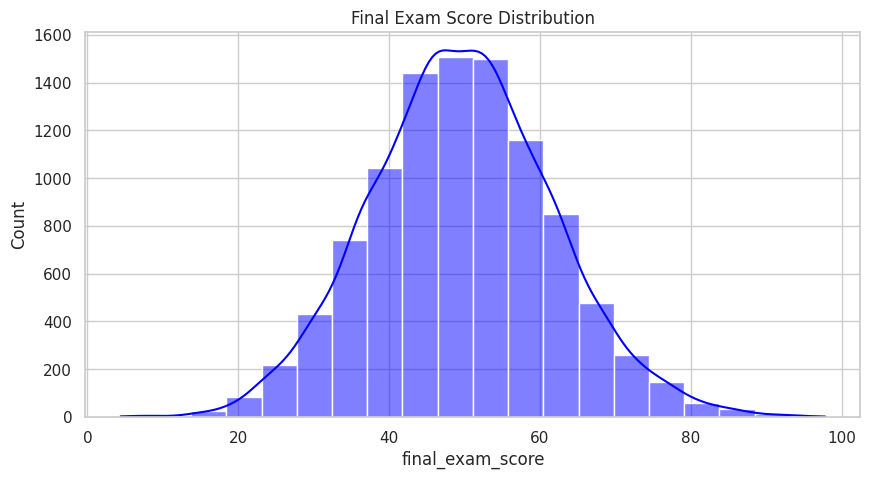

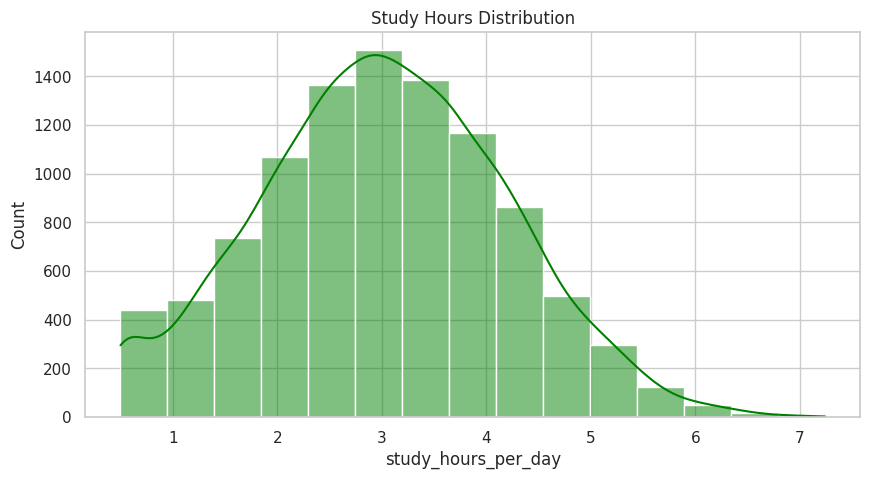

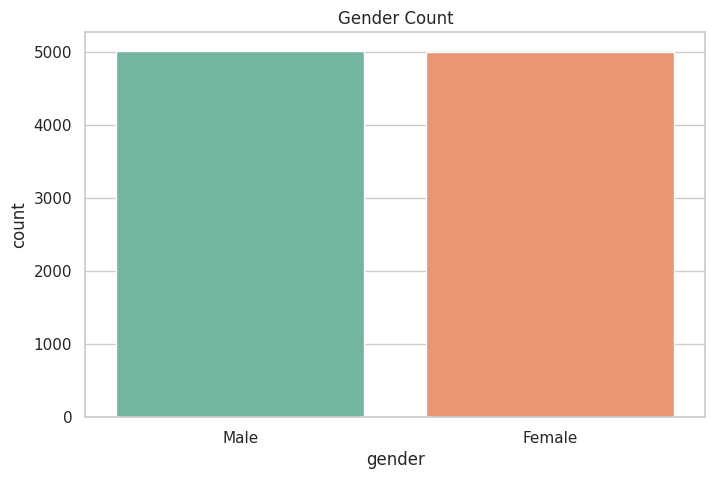

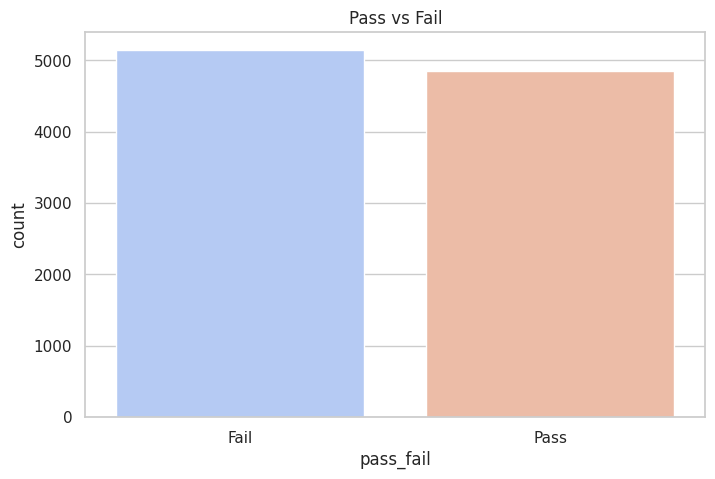

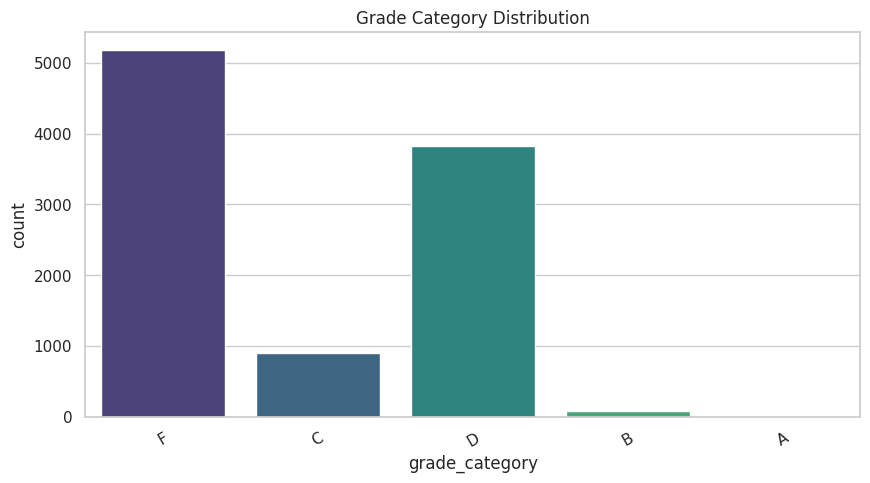

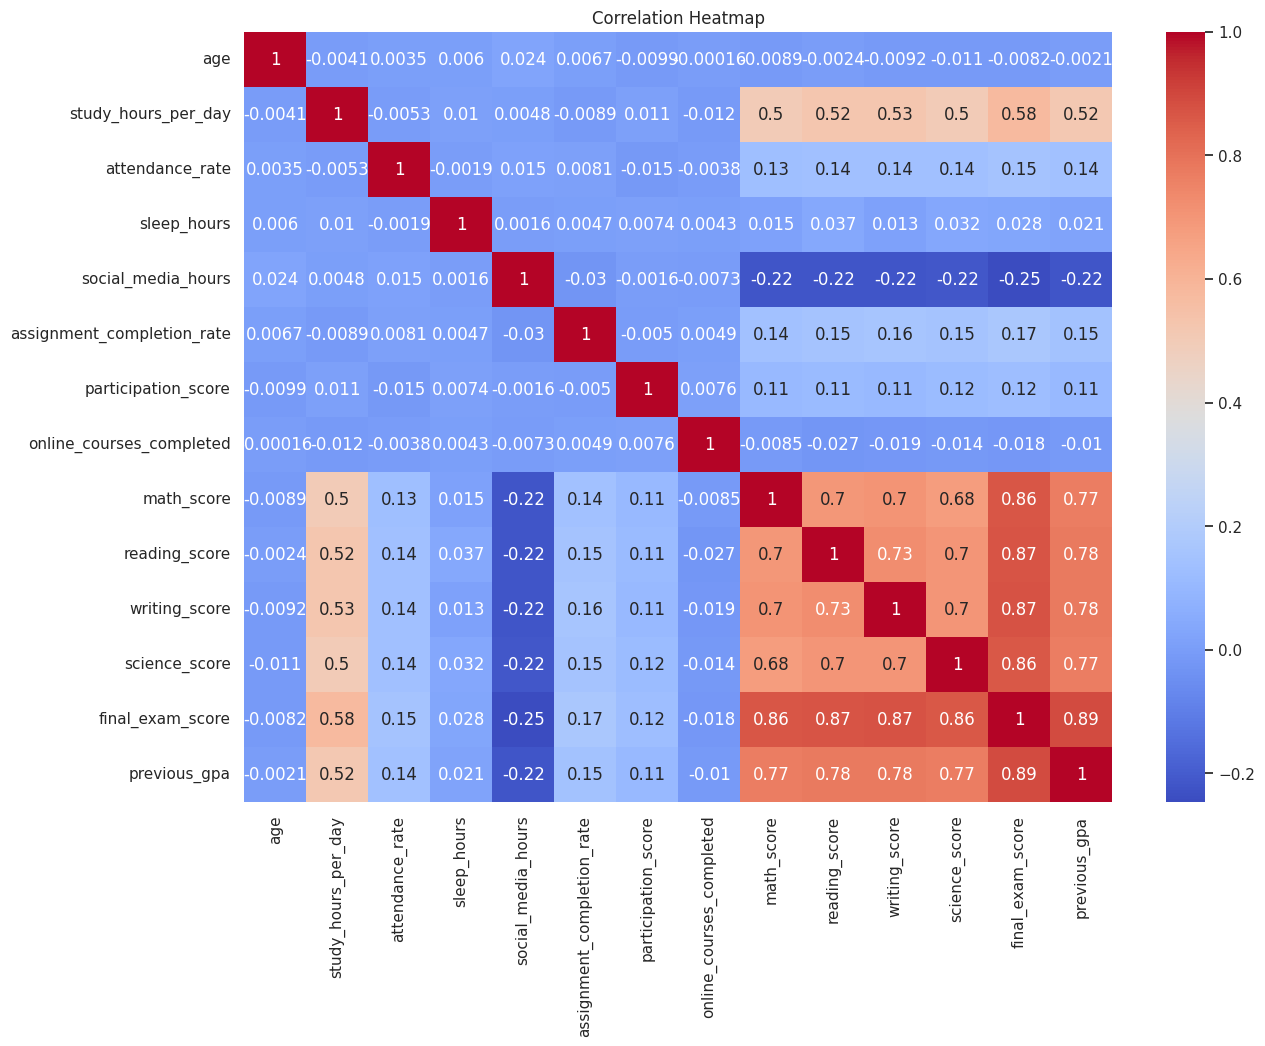

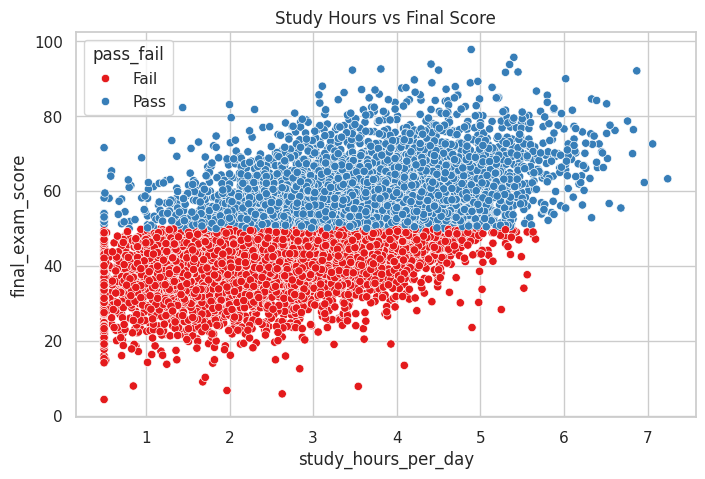

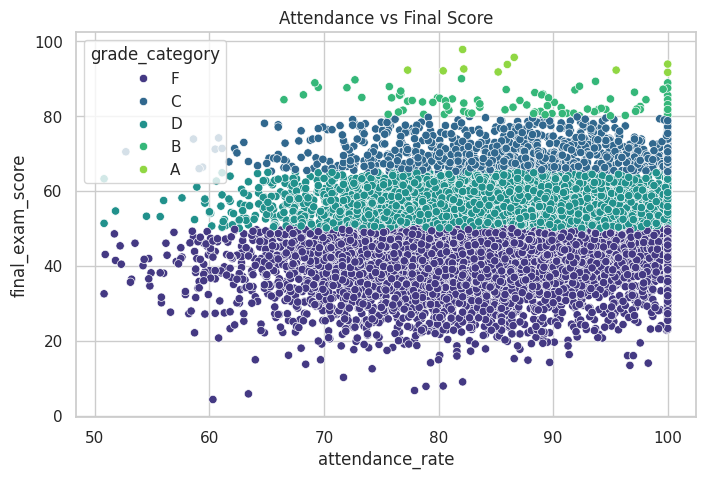

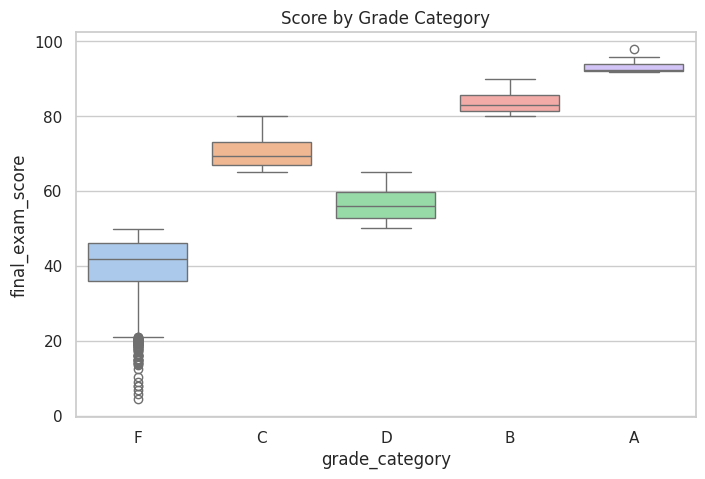

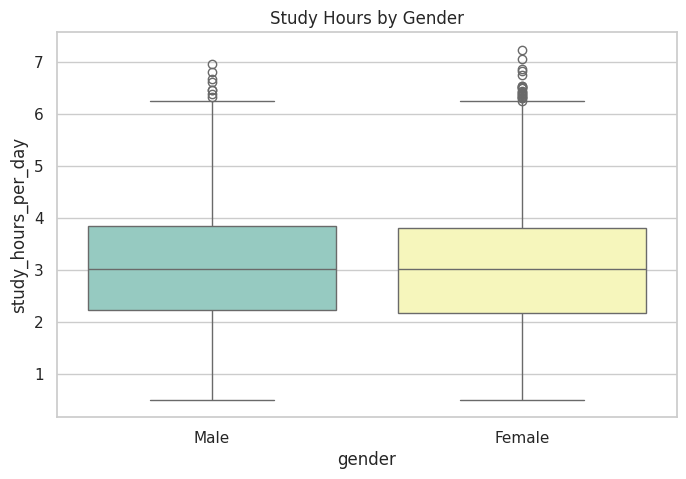

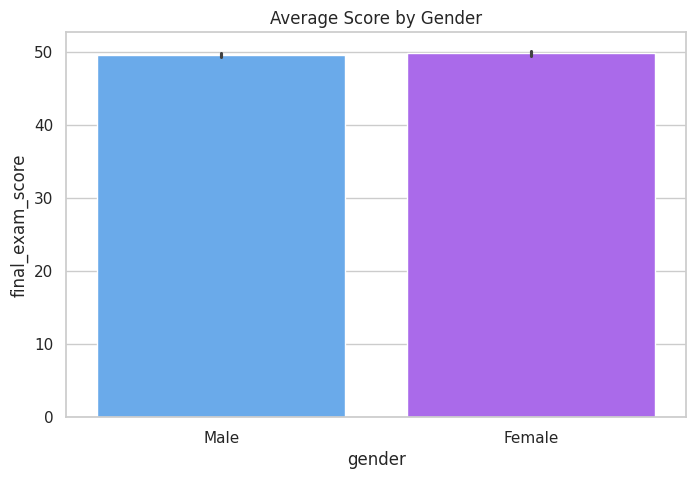

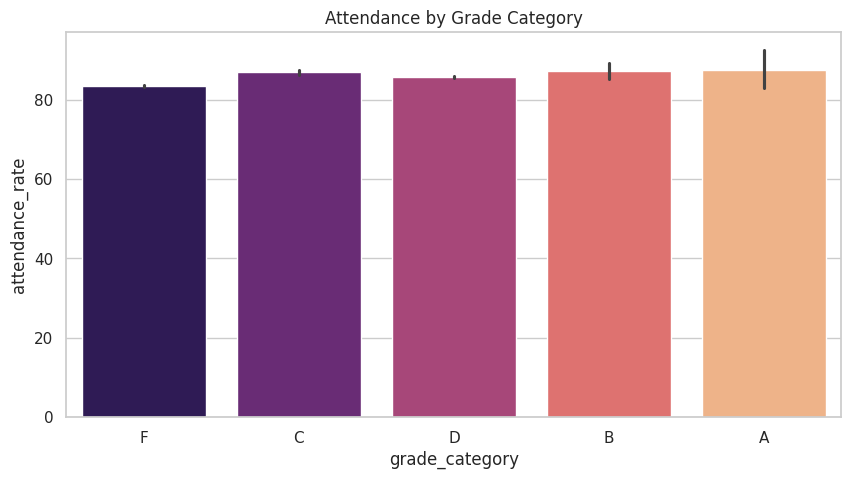

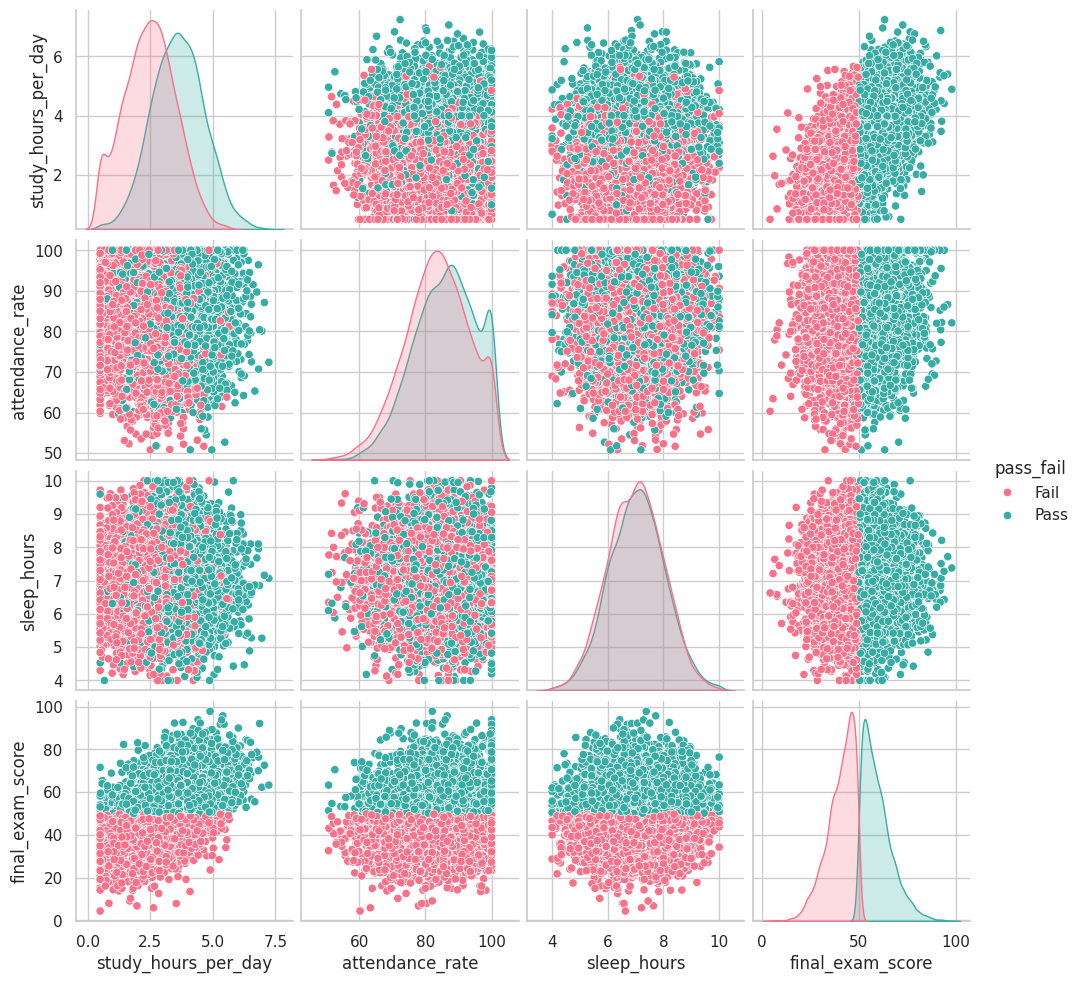

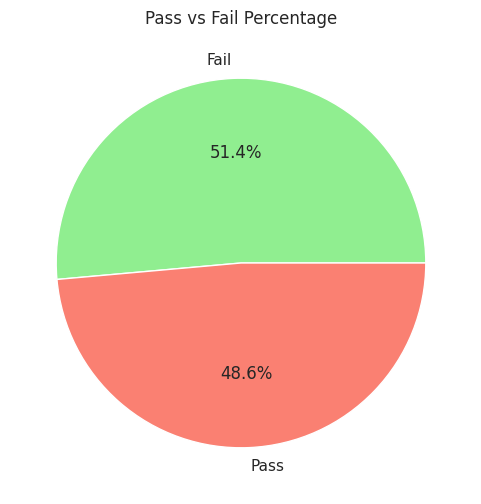

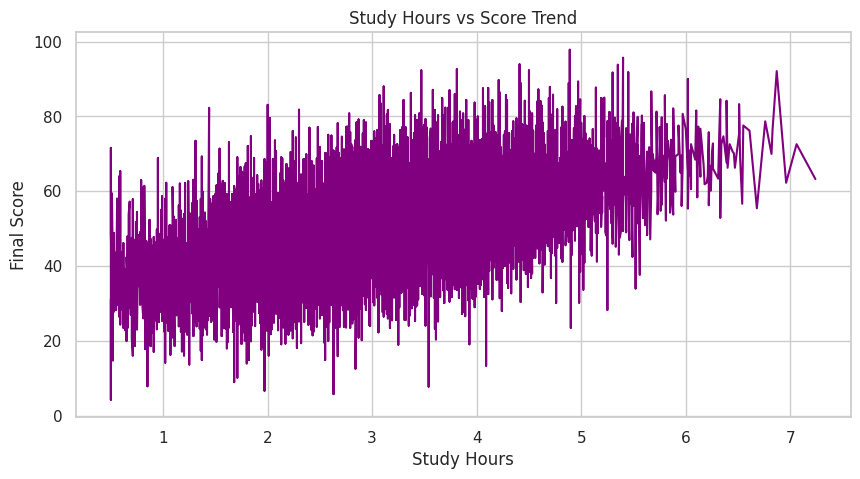

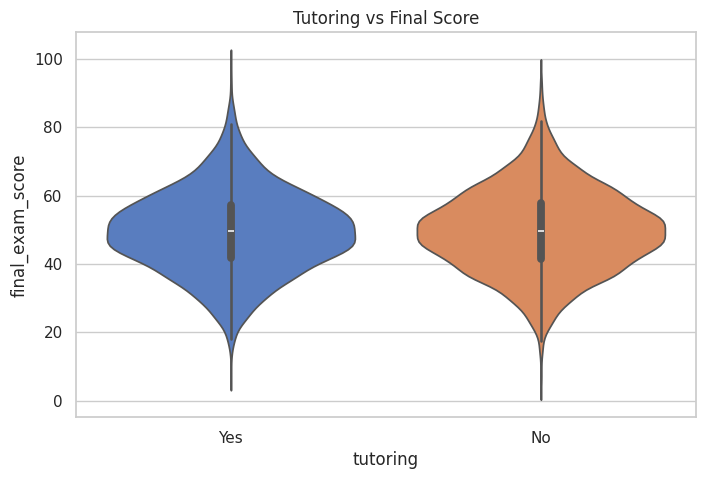

In [12]:
# Style
sns.set(style="whitegrid")


# Clean column names (important)
df.columns = df.columns.str.strip()

# =========================
# BASIC CHECK
# =========================
print(df.columns)
print(df.head())

# =========================
# 1. DISTRIBUTION PLOTS
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df['final_exam_score'], bins=20, kde=True, color='blue')
plt.title("Final Exam Score Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['study_hours_per_day'], bins=15, kde=True, color='green')
plt.title("Study Hours Distribution")
plt.show()

# =========================
# 2. COUNT PLOTS
# =========================
plt.figure(figsize=(8,5))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Count")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='pass_fail', data=df, palette='coolwarm')
plt.title("Pass vs Fail")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='grade_category', data=df, palette='viridis')
plt.title("Grade Category Distribution")
plt.xticks(rotation=30)
plt.show()

# =========================
# 3. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 4. SCATTER PLOTS
# =========================
plt.figure(figsize=(8,5))
sns.scatterplot(x='study_hours_per_day',
                y='final_exam_score',
                hue='pass_fail',
                palette='Set1',
                data=df)
plt.title("Study Hours vs Final Score")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='attendance_rate',
                y='final_exam_score',
                hue='grade_category',
                palette='viridis',
                data=df)
plt.title("Attendance vs Final Score")
plt.show()

# =========================
# 5. BOX PLOTS
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(x='grade_category',
            y='final_exam_score',
            palette='pastel',
            data=df)
plt.title("Score by Grade Category")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='gender',
            y='study_hours_per_day',
            palette='Set3',
            data=df)
plt.title("Study Hours by Gender")
plt.show()

# =========================
# 6. BAR PLOTS
# =========================
plt.figure(figsize=(8,5))
sns.barplot(x='gender',
            y='final_exam_score',
            data=df,
            palette='cool')
plt.title("Average Score by Gender")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='grade_category',
            y='attendance_rate',
            data=df,
            palette='magma')
plt.title("Attendance by Grade Category")
plt.show()

# =========================
# 7. PAIRPLOT (FIXED)
# =========================
sns.pairplot(df[['study_hours_per_day',
                 'attendance_rate',
                 'sleep_hours',
                 'final_exam_score',
                 'pass_fail']],
             hue='pass_fail',
             palette='husl')

plt.show()

# =========================
# 8. PIE CHART
# =========================
plt.figure(figsize=(6,6))
df['pass_fail'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['lightgreen', 'salmon']
)
plt.title("Pass vs Fail Percentage")
plt.ylabel("")
plt.show()

# =========================
# 9. LINE PLOT
# =========================
df_sorted = df.sort_values(by='study_hours_per_day')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['study_hours_per_day'],
         df_sorted['final_exam_score'],
         color='purple')
plt.title("Study Hours vs Score Trend")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

# =========================
# 10. VIOLIN PLOT
# =========================
plt.figure(figsize=(8,5))
sns.violinplot(x='tutoring',
               y='final_exam_score',
               palette='muted',
               data=df)
plt.title("Tutoring vs Final Score")
plt.show()

## Feature engineering


Logistic Regression Accuracy: 0.9970
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1028
           1       1.00      0.99      1.00       972

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1028
           1       1.00      1.00      1.00       972

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


SVM Accuracy: 0.9970
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1028
           1       1.00      0.99      1.00       972

    accuracy                           1.00      2000
   macro avg       1.00      1.00   

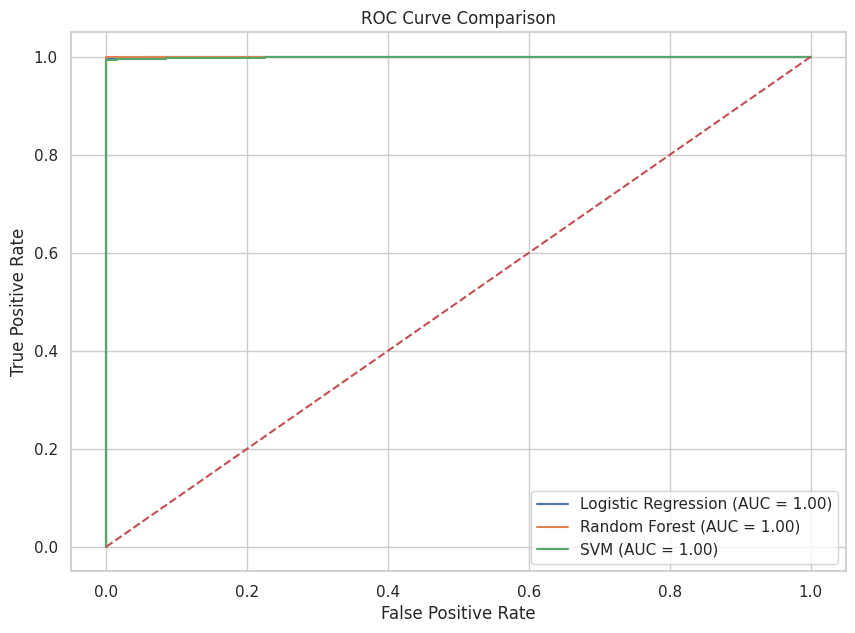


Best Model: Random Forest


In [13]:
# =========================
# IMPORT LIBRARIES
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# =========================
# LOAD DATA
# =========================

df.columns = df.columns.str.strip()

# =========================
# TARGET & FEATURES
# =========================
target = 'pass_fail'

X = df.drop(columns=[target, 'student_id'])  # remove ID
y = df[target]

# =========================
# ENCODE TARGET
# =========================
le = LabelEncoder()
y = le.fit_transform(y)  # Pass=1, Fail=0

# =========================
# IDENTIFY COLUMN TYPES
# =========================
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# =========================
# PREPROCESSING PIPELINE
# =========================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# =========================
# TRAIN TEST SPLIT (NO LEAKAGE)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

# =========================
# TRAIN + EVALUATE
# =========================
results = {}

plt.figure(figsize=(10,7))

for name, model in models.items():
    
    # Create pipeline
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================
# ROC FINAL PLOT
# =========================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# BEST MODEL
# =========================
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)

## Thank you..pls upvote!!!!!!!!!